# Distance Metric Tests

## Setup

### Imports

In [1]:
import logging
from math import isnan

# Local functions and classes
from types_and_classes import *
from utilities import *
from contour_plotting import *
from debug_tools import *
from structure_set import *
from relations import *
from region_slice import empty_structure
from contour_plotting import plot_roi_slice


INFO:metrics.base:Registered calculator: minimum_margins (ContainmentMarginsCalculator)
INFO:metrics.base:Registered calculator: minimum_distance (MinimumDistanceCalculator)


### Global Settings

In [2]:
%matplotlib inline

### b) Function to identify relationships one each slice

In [3]:
def get_slice_relations(structure_a, structure_b):
    slices_a = set(structure_a.region_table['SliceIndex'])
    slices_b = set(structure_b.region_table['SliceIndex'])
    used_slices = slices_a | slices_b

    mask_a = structure_a.region_table.SliceIndex.isin(used_slices) & ~structure_a.region_table.Empty
    mask_b = structure_b.region_table.SliceIndex.isin(used_slices) & ~structure_b.region_table.Empty

    regions_a = structure_a.region_table.loc[mask_a, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions_b = structure_b.region_table.loc[mask_b, ['SliceIndex', 'RegionSlice']].set_index('SliceIndex')
    regions = regions_a.join(regions_b, how='outer', lsuffix='_a', rsuffix='_b').sort_index()

    cumulative = DE27IM()
    slice_rows = []

    for slice_index, row in regions.iterrows():
        region_a = row['RegionSlice_a']
        region_b = row['RegionSlice_b']

        relation = DE27IM(region_a, region_b)
        relation_type = relation.identify_relation()

        cumulative.merge(relation)
        cumulative_type = cumulative.identify_relation()

        slice_rows.append({
            'slice_index': float(slice_index),
            'a_present': not empty_structure(region_a),
            'b_present': not empty_structure(region_b),
            'slice_relation_type': relation_type.relation_type if relation_type else None,
            'slice_relation_label': relation_type.label if relation_type else None,
            'slice_de27im_bits': relation.relation,
            'slice_de27im_int': relation.int,
            'cumulative_relation_type': cumulative_type.relation_type if cumulative_type else None,
            'cumulative_relation_label': cumulative_type.label if cumulative_type else None,
            'cumulative_de27im_bits': cumulative.relation,
            'cumulative_de27im_int': cumulative.int,
        })

    slice_relation_df = pd.DataFrame(slice_rows).sort_values('slice_index').reset_index(drop=True)
    slice_relation_df.set_index('slice_index', inplace=True)
    return slice_relation_df, cumulative

## Distance Tests


### Disjoint Boxes
![Disjoint Boxes](<../../Images/FreeCAD Images/Disjoint Boxes.png>)

In [4]:
def disjoint_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    left_cube = make_box(roi_num=1, width=2, offset_x=-3,
                         spacing=slice_spacing)
    right_cube = make_box(roi_num=2, width=2, offset_x=3,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = left_cube + right_cube + body
    return slice_data


slice_data = disjoint_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'DISJOINT'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be 4 cm (boxes centered at x=-3 and x=3, each with width 2)
# Distance = 3 - 1 - (1 - (-3)) = 6 - 2 = 4 cm
expected_distance = 4.0
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete
INFO:metrics.config:Loading metrics configuration from d:\OneDrive - Queen's University\Python\Projects\StructureRelations\src\metrics\metrics_config.json
INFO:metrics.config:Metrics configuration loaded successfully



left_cube is Disjoint from right_cube
Minimum Distance: 4.00 cm

✓ Distance matches expected value of 4.00 cm


### Disjoint Vertical Boxes
![Disjoint Boxes (Picture not created yet)](<../../Images/FreeCAD Images/Disjoint Vertical Boxes.png>)


In [5]:
def disjoint_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # vertically shifted boxes
    top_cube = make_box(roi_num=1, width=2, offset_z=-3,
                         spacing=slice_spacing)
    bottom_cube = make_box(roi_num=2, width=2, offset_z=3,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = top_cube + bottom_cube + body
    return slice_data


slice_data = disjoint_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nTop Cube {relation_type.label} Bottom Cube')
assert relation_type .relation_type == 'DISJOINT'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be 4 cm (boxes centered at x=-3 and x=3, each with width 2)
# Distance = 3 - 1 - (1 - (-3)) = 6 - 2 = 4 cm
# Both structures will extend an additional distance of s
# lice_spacing / 2 = 0.05 cm in the z-direction, so we need to account for that
# in the expected distance.  Actual distance will be 4 cm - 0,05 x 2 = 3.9 cm
expected_distance = 3.9
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Top Cube is Disjoint from Bottom Cube
Minimum Distance: 3.90 cm

✓ Distance matches expected value of 3.90 cm


### Disjoint Shifted Vertical Boxes
![Disjoint Shifted Boxes (Picture not created yet)](<../../Images/FreeCAD Images/Disjoint Shifted Vertical Boxes.png>)


In [6]:
def disjoint_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # vertically and laterally shifted boxes
    top_cube = make_box(roi_num=1, width=2, offset_z=-3, offset_x=-4,
                         spacing=slice_spacing)
    bottom_cube = make_box(roi_num=2, width=2, offset_z=3, offset_x=0,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = top_cube + bottom_cube + body
    return slice_data


slice_data = disjoint_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nTop Cube {relation_type.label} Bottom Cube')
assert relation_type .relation_type == 'DISJOINT'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be 4 cm (boxes centered at x=-3 and x=3, each with width 2)
# Distance = 3 - 1 - (1 - (-3)) = 6 - 2 = 4 cm
# Top cube is shifted so that its right edge is 2 cm left of of the left edge
# of the bottom cube. Combining the vertical and horizontal distances, gives a
# minimum distance of sqrt(2^2 + 4^2) = 4.47.
expected_distance = 4.47
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Top Cube is Disjoint from Bottom Cube
Minimum Distance: 4.47 cm

✓ Distance matches expected value of 4.47 cm


### Disjoint Concentric Cylinders
- Centred vertical cylinder with two cylinders on the same axis, positioned above and below.
- Regular contours are 2 slices apart (2 cm gap).
- Boundary slices (extrapolated ±0.5 slice spacing) are 1 cm apart.

![Disjoint Concentric Cylinders](<../../Images/FreeCAD Images/Disjoint Concentric Cylinders.png>)


In [7]:
def disjoint_concentric_cylinders_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=12, length=10,
                                  spacing=slice_spacing)
    # Centred cylinder
    # Regular contours: z=-4 to z=4 (9 slices)
    # Boundary slices: z=-4.5 and z=4.5 (extrapolated ±0.5 slice spacing)
    primary_cylinder = make_vertical_cylinder(roi_num=1, radius=3, length=8,
                                              offset_z=0,
                                              spacing=slice_spacing)
    # Upper cylinder with SAME radius (3 cm) for pure vertical distance
    # cylinder 2 slices above primary: z=6 to z=10 (first regular contour at z=6)
    # Gap between regular contours: 6-4 = 2 slices
    # Gap between boundary slices: (6-0.5) - (4+0.5) = 1 cm
    upper_cylinder1 = make_vertical_cylinder(roi_num=2, radius=3, length=4,
                                             offset_z=8,
                                             spacing=slice_spacing)
    # Lower cylinder with SAME radius (3 cm)
    # cylinder 2 slices below primary: z=-10 to z=-6 (last regular at z=-6)
    # Gap between regular contours: (-4)-(-6) = 2 slices
    # Gap between boundary slices: (-4-0.5) - (-6+0.5) = 1 cm
    lower_cylinder2 = make_vertical_cylinder(roi_num=2, radius=3, length=4,
                                             offset_z=-8,
                                             spacing=slice_spacing)
    # combine the contours
    slice_data = body + primary_cylinder + upper_cylinder1 + lower_cylinder2
    return slice_data


slice_data = disjoint_concentric_cylinders_example()
structures = StructureSet(slice_data)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nupper_and_lower_Cylinders {relation_type.label} primary_cylinder')
assert relation_type .relation_type == 'DISJOINT'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = structures.calculate_metric(1, 2, 'minimum_distance')
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Verify: Solid-structure distance calculation
# Expected: Distance should be 1 cm (boundary slices are 1 cm apart)
# Primary cylinder regular contours: z=-4 to z=4
# Upper/Lower cylinder regular contours: z=6 to z=10 and z=-10 to z=-6
# Regular contour gap: 2 slices (2 cm)
# Boundary slice gap: 1 cm (boundaries extrapolate ±0.5 slice spacing)
# Primary boundary: z=4.5, Upper boundary: z=5.5, gap = 1.0 cm
# For SOLID structures, distance is measured between filled polygons, not just boundaries
expected_distance = 1.0
print(f"Expected: {expected_distance} cm")
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Borders
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_1 (ROI 1) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



upper_and_lower_Cylinders is Disjoint from primary_cylinder
Minimum Distance: 1.00 cm
Expected: 1.0 cm

✓ Distance matches expected value of 1.00 cm


### Disjoint Parallel Cylinders
- Concentric hollow cylinder surrounding one of two smaller cylinders
- Second cylinder is parallel, but **Disjoint**.
- The relationship is **Disjoint** because the Second cylinder is outside of the First Structure, but doe not intersect the First Structure.

![Disjoint Parallel Cylinders](<../../Images/FreeCAD Images/Disjoint Parallel Cylinders.png>)

In [8]:
def parallel_disjoint_cylinder_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=25, length=16, offset_z=0,
                                  spacing=slice_spacing)
    outer_cylinder = make_vertical_cylinder(roi_num=1, radius=6, length=10,
                                            spacing=slice_spacing)
    cylinder_hole = make_vertical_cylinder(roi_num=1, radius=5, length=8,
                                           spacing=slice_spacing)
    inner_cylinder = make_vertical_cylinder(roi_num=2, radius=3, length=6,
                                                 spacing=slice_spacing)

    disjoint_cylinder = make_vertical_cylinder(roi_num=2, radius=3, length=6,
                                                 offset_x=10, spacing=slice_spacing)
    # combine the contours
    slice_data = body + outer_cylinder + cylinder_hole + inner_cylinder + disjoint_cylinder
    return slice_data


slice_data = parallel_disjoint_cylinder_example()
structures = StructureSet(slice_data)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nLarger Cylinder {relation_type.label} Smaller Cylinders')
assert relation_type .relation_type == 'DISJOINT'
# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = structures.calculate_metric(1, 2, 'minimum_distance')
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Verify: Solid-structure distance calculation
# Expected: Distance should be 1 cm (Distance between larger hollow cylinder and exterior
# cylinder)  Distances from to interior cylinder will be greater.
expected_distance = 1.0
print(f"Expected: {expected_distance:.2f} cm")
# Tolerance of 0.02 cm (0.2 mm) accounts for polygon discretization
assert abs(distance_result.minimum_distance - expected_distance) < 0.02, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Larger Cylinder is Disjoint from Smaller Cylinders
Minimum Distance: 1.00 cm
Expected: 1.00 cm

✓ Distance matches expected value of 1.00 cm


### Disjoint Parallel Cylinders (with different sized inner cylinders)
- Concentric hollow cylinder surrounding fatter of two smaller cylinders
- Second cylinder is parallel, but **Disjoint**.
- The relationship is **Disjoint** because the Second cylinder is outside of the First Structure, but dose not intersect the First Structure.

![Disjoint Parallel Cylinders](<../../Images/FreeCAD Images/Disjoint Parallel Cylinders.png>)

In [9]:
def parallel_disjoint_different_sized_cylinder_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=25, length=16, offset_z=0,
                                  spacing=slice_spacing)
    outer_cylinder = make_vertical_cylinder(roi_num=1, radius=6, length=10,
                                            spacing=slice_spacing,
                                            num_points=100)
    cylinder_hole = make_vertical_cylinder(roi_num=1, radius=5, length=8,
                                           spacing=slice_spacing,
                                            num_points=100)
    inner_cylinder = make_vertical_cylinder(roi_num=2, radius=4.5, length=6,
                                                 spacing=slice_spacing,
                                            num_points=100)
    disjoint_cylinder = make_vertical_cylinder(roi_num=2, radius=3, length=6,
                                                 offset_x=10, spacing=slice_spacing,
                                            num_points=100)
    # combine the contours
    slice_data = body + outer_cylinder + cylinder_hole + inner_cylinder + disjoint_cylinder
    return slice_data


slice_data = parallel_disjoint_different_sized_cylinder_example()
structures = StructureSet(slice_data)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nLarger Cylinder {relation_type.label} Smaller Cylinders')
assert relation_type .relation_type == 'DISJOINT'
# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = structures.calculate_metric(1, 2, 'minimum_distance')
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Verify: Solid-structure distance calculation
# Expected: Distance should be 0.5 cm, the distance from wall of the hollow
# cylinder to interior cylinder. (Distance from the hollow cylinder to the
# exterior cylinder will be greater).
expected_distance = 0.5
print(f"Expected: {expected_distance:.2f} cm")
# Tolerance of 0.02 cm (0.2 mm) accounts for polygon discretization
assert abs(distance_result.minimum_distance - expected_distance) < 0.02, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Larger Cylinder is Disjoint from Smaller Cylinders
Minimum Distance: 0.50 cm
Expected: 0.50 cm

✓ Distance matches expected value of 0.50 cm


### Disjoint Axial Cylinders
- Concentric hollow cylinder surrounding one of two smaller cylinders
- Second cylinder is on the same axis as the first, but above, making it **Disjoint**.
- The relationship is **Disjoint** because the Second cylinder is outside of the First Structure.

![Disjoint Parallel Cylinders](<../../Images/FreeCAD Images/Disjoint Axial Cylinders.png>)

In [10]:
def axial_disjoint_cylinder_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=10, length=30, offset_z=0,
                                  spacing=slice_spacing)
    outer_cylinder = make_vertical_cylinder(roi_num=1, radius=6, length=10,
                                            spacing=slice_spacing,
                                            num_points=100)
    cylinder_hole = make_vertical_cylinder(roi_num=1, radius=5, length=8,
                                           spacing=slice_spacing,
                                            num_points=100)
    inner_cylinder = make_vertical_cylinder(roi_num=2, radius=3, length=6,
                                                 spacing=slice_spacing,
                                                 num_points=100)

    disjoint_cylinder = make_vertical_cylinder(roi_num=2, radius=3, length=6,
                                                 offset_z=12, spacing=slice_spacing,
                                                 num_points=100)
    # combine the contours
    slice_data = body + outer_cylinder + cylinder_hole + inner_cylinder + disjoint_cylinder
    return slice_data


slice_data = axial_disjoint_cylinder_example()
structures = StructureSet(slice_data)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()


print(f'\nLarger Cylinder {relation_type.label} Smaller Cylinders')
assert relation_type .relation_type == 'DISJOINT'
# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = structures.calculate_metric(1, 2, 'minimum_distance')
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")
# Verify: Solid-structure distance calculation
# Expected: Distance should be 1 cm, the distance from the larger hollow
# cylinder to the disjoint exterior cylinder. Distance from the hollow cylinder
# to the exterior cylinder is greater than the distance to the interior cylinder.
expected_distance = 1.0
print(f"Expected: {expected_distance:.2f} cm")
# Tolerance of 0.02 cm (0.2 mm) accounts for floating point errors
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: is Partitioned by
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Larger Cylinder is Disjoint from Smaller Cylinders
Minimum Distance: 1.00 cm
Expected: 1.00 cm

✓ Distance matches expected value of 1.00 cm


### Bordering Boxes
![Bordering Boxes](<../../Images/FreeCAD Images/Bordering Boxes.png>)

In [11]:
def bordering_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    left_cube = make_box(roi_num=1, width=2, offset_x=-1,
                         spacing=slice_spacing)
    right_cube = make_box(roi_num=2, width=2, offset_x=1,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = left_cube + right_cube + body
    return slice_data


slice_data = bordering_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'BORDERS'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be 0 (boxes are touching)
expected_distance = 0.0
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Borders
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube Borders right_cube
Minimum Distance: 0.00 cm

✓ Distance matches expected value of 0.00 cm


### Vertically Bordering Boxes
![Vertically Bordering Boxes (Picture not created)](<../../Images/FreeCAD Images/Vertically Bordering Boxes.png>)

In [12]:
def bordering_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    left_cube = make_box(roi_num=1, width=2, offset_x=0, offset_z=1.1,
                         spacing=slice_spacing)
    right_cube = make_box(roi_num=2, width=2, offset_x=0, offset_z=-1,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = left_cube + right_cube + body
    return slice_data


slice_data = bordering_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'BORDERS'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be 0 (boxes are touching)
expected_distance = 0.0
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_1 (ROI 1) as: Borders
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube Borders right_cube
Minimum Distance: 0.00 cm

✓ Distance matches expected value of 0.00 cm


### Confines Bordering Boxes
![Confines Bordering Boxes](<../../Images/FreeCAD Images/Confines Bordering Boxes.png>)

In [13]:
def confined_bordering_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=10, length=1, offset_z=-0.2,
                                spacing=slice_spacing)
    # embedded boxes
    box6 = make_box(roi_num=1, width=6, spacing=slice_spacing)
    hole4 = make_box(roi_num=1, width=4,  spacing=slice_spacing)
    Box4 = make_box(roi_num=2, width=4,  spacing=slice_spacing)

    # combine the contours
    slice_data = body + box6 + hole4 + Box4
    return slice_data



slice_data = confined_bordering_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'CONFINES'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be 0 (boxes are touching)
expected_distance = 0.0
assert abs(distance_result.minimum_distance - expected_distance) < 0.01, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)


INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Overlaps with
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Overlaps with
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Confines
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube Confines right_cube
Minimum Distance: 0.00 cm

✓ Distance matches expected value of 0.00 cm


### Overlapping Boxes
![Overlapping Boxes (Picture not created)](<../../Images/FreeCAD Images/Overlapping Boxes in Y direction.png>)

In [14]:
def overlapping_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    left_cube = make_box(roi_num=1, width=2, offset_x=0, offset_z=-0.5,
                         spacing=slice_spacing)
    right_cube = make_box(roi_num=2, width=2, offset_x=0, offset_z=0.5,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = left_cube + right_cube + body
    return slice_data


slice_data = overlapping_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'OVERLAPS'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be NaN (boxes are overlapping)
expected_distance = 0.0
assert isnan(distance_result.minimum_distance), \
    f"Expected NaN, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of NaN")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Overlaps with
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube Overlaps with right_cube
Minimum Distance: nan cm

✓ Distance matches expected value of NaN


### Embedded Boxes
![Embedded Boxes](<../../Images/FreeCAD Images/Embedded Boxes.png>)

In [15]:
def embedded_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    large_cube = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    small_cube = make_box(roi_num=2, width=2, offset_x=0, offset_z=0,
                         spacing=slice_spacing)
    # combine the contours
    slice_data = large_cube + small_cube + body
    return slice_data


slice_data = embedded_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'CONTAINS'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be NaN (boxes are overlapping)
expected_distance = 0.0
assert isnan(distance_result.minimum_distance), \
    f"Expected NaN, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of NaN")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube Contains right_cube
Minimum Distance: nan cm

✓ Distance matches expected value of NaN


### Equal Boxes
![Equal Boxes (Picture not created)](<../../Images/FreeCAD Images/Equal Boxes.png>)

In [16]:
def embedded_boxes_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=20, length=20, offset_z=0,
                                  spacing=slice_spacing)
    # laterally shifted boxes
    cube_1 = make_box(roi_num=1, width=4, offset_x=0, offset_z=0,
                      spacing=slice_spacing)
    cube_2 = make_box(roi_num=2, width=4, offset_x=0, offset_z=0,
                      spacing=slice_spacing)

    # combine the contours
    slice_data = cube_1 + cube_2 + body
    return slice_data


slice_data = embedded_boxes_example()
disjoint_structures = StructureSet(slice_data)
structure_a = disjoint_structures.structures[1]
structure_b = disjoint_structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nleft_cube {relation_type.label} right_cube')
assert relation_type .relation_type == 'EQUAL'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = disjoint_structures.calculate_metric(1, 2, 'minimum_distance')

# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Expected: Distance should be NaN (boxes are equal)
expected_distance = 0.0
assert isnan(distance_result.minimum_distance), \
    f"Expected NaN, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of NaN")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Equal to
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



left_cube is Equal to right_cube
Minimum Distance: nan cm

✓ Distance matches expected value of NaN


# Done to Here

- Some of the tests below are currently failing.
- Some of the tests below are expected to fail when boundary scaling is corrected.
- Some of the tests below have not been fully implemented yet.

### Vertically Disjoint Cylinders and Ring
- Centred hollow vertical cylinder with two cylinders on the same axis, positioned above and below.
- Regular contours are 2 slices apart (2 cm gap).
- Boundary slices (extrapolated ±0.5 slice spacing) are 1 cm apart.
- Ring and cylinder are the same size, so overall distance is 1.0 cm.

![Vertically Disjoint Cylinders and Ring (Picture Not Yet Created)](<../../Images/FreeCAD Images/Vertically Disjoint Cylinders and Ring.png>)


In [17]:
def vertically_disjoint_cylinders_and_ring_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=12, length=10,
                                  spacing=slice_spacing)
    # Centred cylinder
    # Regular contours: z=-4 to z=4 (9 slices)
    # Boundary slices: z=-4.5 and z=4.5 (extrapolated ±0.5 slice spacing)
    primary_cylinder = make_vertical_cylinder(roi_num=1, radius=5, length=8,
                                              offset_z=0,
                                              spacing=slice_spacing)
    # Hole in the primary cylinder with smaller radius (4 cm) to create a ring
    # structure
    cylinder_hole = make_vertical_cylinder(roi_num=1, radius=4, length=8,
                                              offset_z=0,
                                              spacing=slice_spacing)
    # Upper cylinder with SAME radius (4 cm) for pure vertical distance
    # cylinder 2 slices above primary: z=6 to z=10 (first regular contour at z=6)
    # Gap between regular contours: 6-4 = 2 slices
    # Gap between boundary slices: (6-0.5) - (4+0.5) = 1 cm
    upper_cylinder1 = make_vertical_cylinder(roi_num=2, radius=5, length=4,
                                             offset_z=8,
                                             spacing=slice_spacing)
    # Lower cylinder with SAME radius (4 cm)
    # cylinder 2 slices below primary: z=-10 to z=-6 (last regular at z=-6)
    # Gap between regular contours: (-4)-(-6) = 2 slices
    # Gap between boundary slices: (-4-0.5) - (-6+0.5) = 1 cm
    lower_cylinder2 = make_vertical_cylinder(roi_num=2, radius=5, length=4,
                                             offset_z=-8,
                                             spacing=slice_spacing)
    # combine the contours
    slice_data = body + primary_cylinder + cylinder_hole + upper_cylinder1 + lower_cylinder2
    return slice_data


slice_data = vertically_disjoint_cylinders_and_ring_example()
structures = StructureSet(slice_data)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nupper_and_lower_Cylinders {relation_type.label} primary_cylinder')
assert relation_type .relation_type == 'DISJOINT'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = structures.calculate_metric(1, 2, 'minimum_distance')
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Verify: Solid-structure distance calculation
# Expected: Distance should be 1 cm (boundary slices are 1 cm apart)
expected_distance = 1.0
print(f"Expected: {expected_distance:.2f} cm")
# Tolerance of 0.02 cm (0.2 mm) accounts for polygon discretization
assert abs(distance_result.minimum_distance - expected_distance) < 0.02, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Borders
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_2 (ROI 2) and Structure_1 (ROI 1) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



upper_and_lower_Cylinders is Disjoint from primary_cylinder
Minimum Distance: 1.00 cm
Expected: 1.00 cm

✓ Distance matches expected value of 1.00 cm


### Vertically Disjoint Different Sized Cylinders and Ring
- Same as above except the the lower cylinder is smaller in diameter.
- This confirms that distance selected the minimum values from the two Z gaps.

![Vertically Disjoint Cylinders and Ring (Picture Not Yet Created)](<../../Images/FreeCAD Images/Vertically Disjoint Cylinders and Ring.png>)


In [18]:
def vertically_disjoint_cylinders_and_ring_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=12, length=10,
                                  spacing=slice_spacing)
    # Centred cylinder
    # Regular contours: z=-4 to z=4 (9 slices)
    # Boundary slices: z=-4.5 and z=4.5 (extrapolated ±0.5 slice spacing)
    primary_cylinder = make_vertical_cylinder(roi_num=1, radius=5, length=8,
                                              offset_z=0,
                                              spacing=slice_spacing)
    # Hole in the primary cylinder with smaller radius (4 cm) to create a ring
    # structure
    cylinder_hole = make_vertical_cylinder(roi_num=1, radius=4, length=8,
                                              offset_z=0,
                                              spacing=slice_spacing)
    # Upper cylinder with SMALLER radius (3 cm) for pure vertical distance
    # cylinder 2 slices above primary: z=6 to z=10 (first regular contour at z=6)
    # Gap between regular contours: 6-4 = 2 slices
    # Gap between boundary slices: (6-0.5) - (4+0.5) = 1 cm
    upper_cylinder1 = make_vertical_cylinder(roi_num=2, radius=3, length=4,
                                             offset_z=8,
                                             spacing=slice_spacing)
    # Lower cylinder with SMALLER radius (3 cm)
    # cylinder 2 slices below primary: z=-10 to z=-6 (last regular at z=-6)
    # Gap between regular contours: (-4)-(-6) = 2 slices
    # Gap between boundary slices: (-4-0.5) - (-6+0.5) = 1 cm
    lower_cylinder2 = make_vertical_cylinder(roi_num=2, radius=3, length=4,
                                             offset_z=-8,
                                             spacing=slice_spacing)
    # combine the contours
    slice_data = body + primary_cylinder + cylinder_hole + upper_cylinder1 + lower_cylinder2
    return slice_data


slice_data = vertically_disjoint_cylinders_and_ring_example()
structures = StructureSet(slice_data)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nupper_and_lower_Cylinders {relation_type.label} primary_cylinder')
assert relation_type .relation_type == 'DISJOINT'

# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = structures.calculate_metric(1, 2, 'minimum_distance')
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Verify: Solid-structure distance calculation
# Expected: Distance should be 1 cm (boundary slices are 1 cm apart)
# Primary cylinder regular contours: z=-4 to z=4
# Upper/Lower cylinder regular contours: z=6 to z=10 and z=-10 to z=-6
# Regular contour gap: 2 slices (2 cm)

# Boundary slice gap: 1 cm (boundaries extrapolate ±0.5 slice spacing)
# Primary boundary: z=4.5, Upper boundary: z=5.5, gap = 1.0 cm

# The primary cylinder is hollow, with a 1 cm horizontal gap
# The boundary contours are scaled to half the size hole radius -> 2cm,
# cylinder radius -> 1.5 cm. The horizontal gap between the boundary contours
# will be 0.5 cm. The overall distance between the structures will be
# $\sqrt{0.5^2 + 1^2} = 1.12$ cm
expected_distance = sqrt(0.5**2 + 1**2)  # ≈ 1.12 cm
print(f"Expected: {expected_distance:.2f} cm")
# Tolerance of 0.02 cm (0.2 mm) accounts for polygon discretization
assert abs(distance_result.minimum_distance - expected_distance) < 0.02, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Borders
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



upper_and_lower_Cylinders is Disjoint from primary_cylinder
Minimum Distance: 1.11 cm
Expected: 1.12 cm

✓ Distance matches expected value of 1.12 cm


# Known Fail
This test fails because the boundary scaling does not take into account that 
the centre is hollow.  As a result, when the boundary contour scales the hollow 
region also shrinks.  Since the inner cylinder is not at a boundary, it does 
not scale

### Extended Inner Cylinder
- Concentric hollow cylinder with an interior cylinder extending beyond the outer cylinder's hole by one slice

![Extended Inner Cylinder](<../../Images/FreeCAD Images/Extended Inner cylinder.png>)

In [19]:
def extended_inner_cylinder_example():
    slice_spacing = 1
    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=12, length=16, offset_z=0,
                                  spacing=slice_spacing,
                                  num_points=100)
    outer_cylinder = make_vertical_cylinder(roi_num=1, radius=6, length=10,
                                            spacing=slice_spacing,
                                            num_points=100)
    cylinder_hole = make_vertical_cylinder(roi_num=1, radius=5, length=10,
                                           spacing=slice_spacing,
                                           num_points=100)
    inner_cylinder = make_vertical_cylinder(roi_num=2, radius=3, length=12,
                                            spacing=slice_spacing,
                                            num_points=100)

    # combine the contours
    slice_data = body + outer_cylinder + cylinder_hole + inner_cylinder
    return slice_data


slice_data = extended_inner_cylinder_example()
structures = StructureSet(slice_data)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Hollow Cylinder {relation_type.label} Inner Cylinder')
assert relation_type .relation_type == 'DISJOINT'
# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = structures.calculate_metric(1, 2, 'minimum_distance')
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Verify: Solid-structure distance calculation
# Expected: Distance should be 2 cm (Gap between inner solid cylinder and outer
# cylinder)  Distances from boundary slices will be greater.
expected_distance = 2.0
print(f"Expected: {expected_distance:.2f} cm")
# Tolerance of 0.02 cm (0.2 mm) accounts for polygon discretization
#assert abs(distance_result.minimum_distance - expected_distance) < 0.02, \
#    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
#print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Calculating relationships for 3 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculating logical flags for relationships
INFO:structure_set:Logical flag calculation complete



Outer Hollow Cylinder is Disjoint from Inner Cylinder
Minimum Distance: 0.00 cm
Expected: 2.00 cm


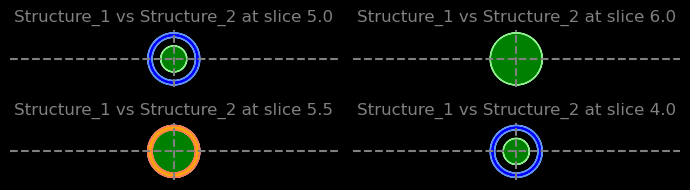

In [20]:
tolerance = 0.01
# Create figure and plot
fig, ax = plt.subplots(2, 2, figsize=(7, 2))
slice_idx = 5.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[0,0], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 6.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[0,1], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 5.5
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[1,0], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 4.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[1,1], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()


### Horizontal Disjoint Cylinders
- Same as above but with horizontal cylinders
- Cylindrical shell with an interior cylinder ending outside the larger 
    diameter cylinder
- The relationship is **Disjoint** because the Second cylinder extends beyond 
    the horizontal bounds of the First Structure, but doe not intersect the 
    First Structure.

In [21]:
def disjoint_horizontal_cylinder_example(slice_spacing):

    # Body structure defines slices in use
    body = make_vertical_cylinder(roi_num=0, radius=12, length=16, offset_z=0,
                                  spacing=slice_spacing)
    outer_cylinder = make_horizontal_cylinder(roi_num=1, radius=6, length=10,
                                              spacing=slice_spacing)
    cylinder_hole = make_horizontal_cylinder(roi_num=1, radius=5, length=10,
                                             spacing=slice_spacing)
    surrounded_cylinder = make_horizontal_cylinder(roi_num=2, radius=3,
                                                   length=12,
                                                   spacing=slice_spacing)
    # This structure is added to clarify the extent of the hole.
    bordering_cylinder = make_horizontal_cylinder(roi_num=3, radius=5, length=10,
                                                  spacing=slice_spacing)
    # combine the contours
    slice_data = body + outer_cylinder + cylinder_hole + surrounded_cylinder + bordering_cylinder
    return slice_data

slice_spacing = 1
slice_data = disjoint_horizontal_cylinder_example(slice_spacing)
structures = StructureSet(slice_data)
structure_a = structures.structures[1]
structure_b = structures.structures[2]
relation = structure_a.relate(structure_b)
relation_type = relation.identify_relation()

print(f'\nOuter Hollow Cylinder {relation_type.label} Inner Cylinder')
assert relation_type .relation_type == 'DISJOINT'
# Calculate minimum distance between the two boxes (ROI 1 and ROI 2)
distance_result = structures.calculate_metric(1, 2, 'minimum_distance')
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")

# Verify: Solid-structure distance calculation
# Expected: Distance should be 2 cm (Gap between inner solid cylinder and outer
# cylinder)  Distances from boundary slices will be greater.
expected_distance = 2.0  # ≈ 1.41 cm
# subtract an additional distance of slice_spacing / 2 for the inner structure
# to account for extension beyond regular contours.  Since it is inside a hole a
# second slice_spacing / 2 not subtracted for the outer structure to account.
expected_distance -= slice_spacing / 2
print(f"Expected: {expected_distance:.2f} cm")
# Tolerance of 0.02 cm (0.2 mm) accounts for polygon and slice discretization
tolerance = slice_spacing / 2.0
assert abs(distance_result.minimum_distance - expected_distance) < tolerance, \
    f"Expected {expected_distance:.2f} cm, got {distance_result.minimum_distance:.2f} cm"
print(f"\n✓ Distance matches expected value of {expected_distance:.2f} cm")

INFO:structure_set:Adding structure Structure_0 (0)
INFO:structure_set:Adding structure Structure_1 (1)
INFO:structure_set:Adding structure Structure_2 (2)
INFO:structure_set:Adding structure Structure_3 (3)
INFO:structure_set:Calculating relationships for 4 structures
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_1 (ROI 1) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_3 (ROI 3) as: Contains
INFO:structure_set:Calculated relationships between Structure_0 (ROI 0) and Structure_2 (ROI 2) as: Contains
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_3 (ROI 3) as: Borders
INFO:structure_set:Calculated relationships between Structure_1 (ROI 1) and Structure_2 (ROI 2) as: is Disjoint from
INFO:structure_set:Calculated relationships between Structure_3 (ROI 3) and Structure_2 (ROI 2) as: Overlaps with
INFO:structure_set:Calculating logical flags for relationships
I


Outer Hollow Cylinder is Disjoint from Inner Cylinder
Minimum Distance: 1.50 cm
Expected: 1.50 cm

✓ Distance matches expected value of 1.50 cm


# Not Done

#### Shelters with opening on the plane of the slices
  - $X_{pos}$ Margin and Z Margins are NaN

<img width="250px" src="../../Images/FreeCAD Images/Sheltered Horizontal cylinder End On View.png" alt="Sheltered Horizontal cylinder">

In [22]:
def vertical_sheltered_cylinder_example():
    slice_spacing = 0.1
    # Body structure defines slices in use
    # This is required to get the correct boundary slices for the outer cube.
    body = make_vertical_cylinder(roi_num=0, radius=20, length=10, offset_z=0,
                                  spacing=slice_spacing)

    outer_circle = Polygon(circle_points(radius=4.0, num_points=256))
    outer_hole = Polygon(circle_points(3.0, num_points=256))
    # A large rectangle keeps slightly more than the left half of C polygon.
    right_half_plane = Polygon(box_points(width=8.0, offset_x=5.5, offset_y=0))
    outer_c_polygon = outer_circle.difference(outer_hole) - right_half_plane
    outer_c = extrude_poly(outer_c_polygon, length=4.0, spacing=slice_spacing,
                           roi_num=1)

    inner_circle = Polygon(circle_points(radius=2.0, num_points=256,
                                         offset_x=0, offset_y=0))
    # A large rectangle keeps the left half of the inner circular polygon.
    right_inner_half_plane = Polygon(box_points(width=4.0, offset_x=2.0,
                                               offset_y=0))
    inner_semicircle_polygon = inner_circle.difference(right_inner_half_plane)
    inner_semicircle = extrude_poly(inner_semicircle_polygon, length=4.0,
                                    spacing=slice_spacing, roi_num=2)

    slice_data = outer_c + inner_semicircle + body
    return slice_data


## Other distance tests to do:
- embedded hollow spheres
- multiple disjoint regions with different distances
- multiple regions each bordering a corresponding region in the other structure (distance should be 0).
- Check storage of intermediate results.
  - Slice by slice distance values
  - Individual region distances
  - Slice by slice distance values for each region


## Other things to do
- Create FreeCad images for each test example
- Check documentation for tests to confirm that comments match implementation
- Create a test suite for all distance metrics

## Debugging code

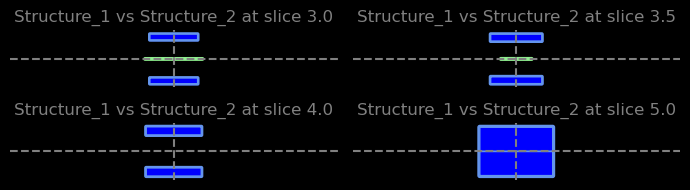

In [23]:
# Create figure and plot
fig, ax = plt.subplots(2, 2, figsize=(7, 2))
slice_idx = 3.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[0,0], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 3.5
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[0,1], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 4.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[1,0], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
slice_idx = 5.0
plot_roi_slice(structures, slice_index=slice_idx,
               roi_list=[1, 2],
               add_axis=True, axes=ax[1,1], tolerance=tolerance,
               plot_mode='relationship', show_legend=False)
plt.tight_layout()
plt.show()


In [24]:
slices = structures.slice_sequence.sequence
slices[~slices.Original]
slices

,ThisSlice,NextSlice,PreviousSlice,Original
ThisSlice,,,,
-8.25,-8.25,-8.0,NaN,False
-8.00,-8.00,-7.0,NaN,True
-7.00,-7.00,-6.0,-8.0,True
-6.50,-6.50,-6.0,-7.0,False
-6.00,-6.00,-5.0,-7.0,True
-5.50,-5.50,-5.0,-6.0,False
-5.00,-5.00,-4.0,-6.0,True
-4.00,-4.00,-3.0,-5.0,True
-3.50,-3.50,-3.0,-4.0,False


Region pair (1, 0):
  Slice -5.0 to -3.5: 1.50 cm
  Slice  5.0 to  3.5: 1.50 cm

Region pair (2, 0):
  Slice -5.5 to -3.5: 2.00 cm
  Slice -5.0 to -3.5: 1.50 cm
  Slice 5.0 to 3.5: 1.50 cm
  Slice 5.5 to 3.5: 2.00 cm

In [25]:
# Examine per-slice distances for detailed analysis
if distance_result.slice_distances:
    print("Per-Slice Distances:")
    for region_pair, slice_dists in distance_result.slice_distances.items():
        print(f"\nRegion pair {region_pair}:")
        for (slice_a, slice_b), dist in sorted(slice_dists.items()):
            print(f"  Slice {slice_a} to {slice_b}: {dist:.2f} cm")

Per-Slice Distances:

Region pair (0, 0):
  Slice -6.5 to -3.5: 3.00 cm
  Slice -6.0 to -3.5: 2.50 cm

Region pair (1, 0):
  Slice -5.5 to -3.5: 2.00 cm
  Slice -5.0 to -3.5: 1.50 cm
  Slice -4.0 to -3.5: 3.04 cm
  Slice -4.0 to -3.0: 3.15 cm
  Slice -3.5 to -3.5: 3.50 cm
  Slice -3.5 to -3.0: 3.53 cm
  Slice -3.5 to -2.0: 1.96 cm
  Slice -3.0 to -3.5: 4.03 cm
  Slice -3.0 to -3.0: 3.99 cm
  Slice -3.0 to -2.0: 2.03 cm
  Slice -2.0 to -3.5: 4.82 cm
  Slice -2.0 to -3.0: 4.68 cm
  Slice -2.0 to -2.0: 2.35 cm
  Slice -2.0 to -1.0: 2.02 cm
  Slice -1.0 to -2.0: 2.84 cm
  Slice -1.0 to -1.0: 2.07 cm
  Slice -1.0 to 0.0: 2.15 cm
  Slice 0.0 to -1.0: 2.39 cm
  Slice 0.0 to 0.0: 2.00 cm
  Slice 0.0 to 1.0: 2.39 cm
  Slice 1.0 to 0.0: 2.15 cm
  Slice 1.0 to 1.0: 2.07 cm
  Slice 1.0 to 2.0: 2.84 cm
  Slice 2.0 to 1.0: 2.02 cm
  Slice 2.0 to 2.0: 2.35 cm
  Slice 2.0 to 3.0: 4.68 cm
  Slice 2.0 to 3.5: 4.82 cm
  Slice 3.0 to 2.0: 2.03 cm
  Slice 3.0 to 3.0: 3.99 cm
  Slice 3.0 to 3.5: 4.03 cm
  S

In [26]:
# Display results
print(f"Minimum Distance: {distance_result.minimum_distance:.2f} cm")
print(f"Closest Region Pair: {distance_result.closest_region_pair}")
print(f"Closest Slice: {distance_result.closest_slice}")

# Per-region distances (if multi-region structures)
if distance_result.per_region_minimum_distance:
    print("\nPer-Region Distances:")
    for region_pair, dist in distance_result.per_region_minimum_distance.items():
        print(f"  Region pair {region_pair}: {dist:.2f} cm")


Minimum Distance: 1.50 cm
Closest Region Pair: (1, 0)
Closest Slice: (np.float64(-5.0), np.float64(-3.5))

Per-Region Distances:
  Region pair (0, 0): 2.50 cm
  Region pair (1, 0): 1.50 cm
  Region pair (2, 0): 1.50 cm
  Region pair (3, 0): 2.00 cm


In [27]:
structure_a = structures.structures[1]
structure_b = structures.structures[2]
slice_relation_df, cumulative = get_slice_relations(structure_a, structure_b)

In [28]:
import sys
import importlib

# Remove cached modules to force reload
modules_to_reload = [k for k in sys.modules.keys() if 'metrics' in k or 'structures' in k or 'relations' in k or 'structure_set' in k]
for module in modules_to_reload:
    del sys.modules[module]

print(f"Cleared {len(modules_to_reload)} cached modules")


Cleared 13 cached modules
